In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [ ]:
df = pd.read_csv('calibration datas/ad595_thermocouple_calibration.csv')
df['temperature_K'] = df['temperature_C'] + 273.15
T = df['temperature_K'].values
V = df['ad595_output_mV'].values

T_smooth = np.linspace(T.min(), T.max(), 500)
T_mean = T.mean()
T_std  = T.std()

df.head()

,temperature_C,ad595_output_mV,temperature_K
0,-200,-1454.0,73.15
1,-180,-1370.0,93.15
2,-160,-1269.0,113.15
3,-140,-1152.0,133.15
4,-120,-1021.0,153.15


In [ ]:
'''

# Pop rows outside the temperature window [130 K, 300 K]
mask_outside = (df["temperature_K"] > 300) | (df["temperature_K"] < 130)

popped_df = df.loc[mask_outside].copy()   # popped values
df = df.loc[~mask_outside].copy()         # remaining values

# Refresh arrays used later
T = df["temperature_K"].values
V = df["ad595_output_mV"].values
T_smooth = np.linspace(T.min(), T.max(), 500)
T_mean = T.mean()
T_std = T.std()

print("Popped rows:", len(popped_df))
display(popped_df.head())
print("Remaining rows:", len(df))
display(df.head())
'''


'\n\n# Pop rows outside the temperature window [130 K, 300 K]\nmask_outside = (df["temperature_K"] > 300) | (df["temperature_K"] < 130)\n\npopped_df = df.loc[mask_outside].copy()   # popped values\ndf = df.loc[~mask_outside].copy()         # remaining values\n\n# Refresh arrays used later\nT = df["temperature_K"].values\nV = df["ad595_output_mV"].values\nT_smooth = np.linspace(T.min(), T.max(), 500)\nT_mean = T.mean()\nT_std = T.std()\n\nprint("Popped rows:", len(popped_df))\ndisplay(popped_df.head())\nprint("Remaining rows:", len(df))\ndisplay(df.head())\n'

In [ ]:
# Helper: compute and print goodness-of-fit stats
def goodness_of_fit(V, V_pred, n_params, label):
    residuals = V - V_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((V - V.mean())**2)
    r2      = 1 - ss_res / ss_tot
    r2_adj  = 1 - (1 - r2) * (len(V) - 1) / (len(V) - n_params - 1)
    rmse    = np.sqrt(np.mean(residuals**2))
    mae     = np.mean(np.abs(residuals))
    chi2_red = ss_res / (len(V) - n_params)
    print(f'=== Goodness of Fit: {label} ===')
    print(f'  R²           = {r2:.8f}')
    print(f'  Adjusted R²  = {r2_adj:.8f}')
    print(f'  RMSE         = {rmse:.4f} mV')
    print(f'  MAE          = {mae:.4f} mV')
    print(f'  Max residual = {np.abs(residuals).max():.4f} mV')
    print(f'  Reduced χ²   = {chi2_red:.4f}')
    print()
    return residuals, r2, rmse

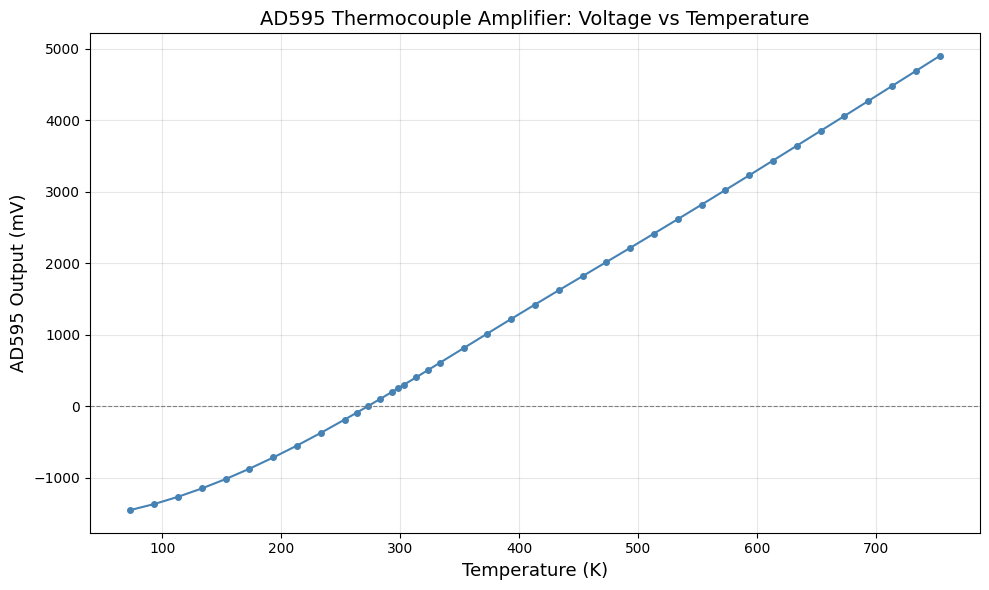

In [ ]:
# Chart 1: Raw data
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(T, V, 'o-', color='steelblue', markersize=4, linewidth=1.5)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Temperature (K)', fontsize=13)
ax.set_ylabel('AD595 Output (mV)', fontsize=13)
ax.set_title('AD595 Thermocouple Amplifier: Voltage vs Temperature', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Goodness of Fit: Linear ===
  R²           = 0.99682764
  Adjusted R²  = 0.99674415
  RMSE         = 106.0015 mV
  MAE          = 79.0442 mV
  Max residual = 388.7589 mV
  Reduced χ²   = 11524.4303

=== Linear Fit: V = m·T + b ===
  m (slope)     = 9.729262 mV/K
  b (intercept) = -2554.4545 mV


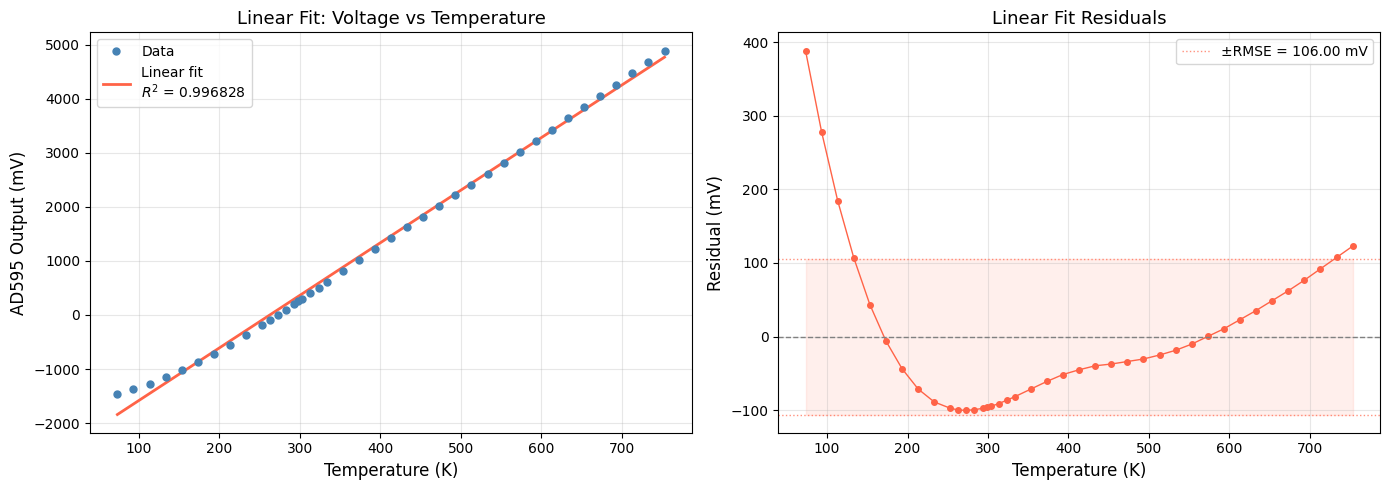

In [ ]:
# --- Linear Fit ---
lin_coeffs = np.polyfit(T, V, 1)
m, b_lin = lin_coeffs
V_lin = np.polyval(lin_coeffs, T)
lin_res, lin_r2, lin_rmse = goodness_of_fit(V, V_lin, 1, 'Linear')

print(f'=== Linear Fit: V = m·T + b ===')
print(f'  m (slope)     = {m:.6f} mV/K')
print(f'  b (intercept) = {b_lin:.4f} mV')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(T, V, 'o', color='steelblue', markersize=5, zorder=3, label='Data')
axes[0].plot(T_smooth, np.polyval(lin_coeffs, T_smooth), '-', color='tomato', linewidth=2,
             label=f'Linear fit\n$R^2$ = {lin_r2:.6f}')
axes[0].set_xlabel('Temperature (K)', fontsize=12)
axes[0].set_ylabel('AD595 Output (mV)', fontsize=12)
axes[0].set_title('Linear Fit: Voltage vs Temperature', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(T, lin_res, 'o-', color='tomato', markersize=4, linewidth=1)
axes[1].axhline(0, color='gray', linewidth=1, linestyle='--')
axes[1].axhline( lin_rmse, color='tomato', linewidth=1, linestyle=':', alpha=0.7, label=f'±RMSE = {lin_rmse:.2f} mV')
axes[1].axhline(-lin_rmse, color='tomato', linewidth=1, linestyle=':', alpha=0.7)
axes[1].fill_between(T, -lin_rmse, lin_rmse, alpha=0.1, color='tomato')
axes[1].set_xlabel('Temperature (K)', fontsize=12)
axes[1].set_ylabel('Residual (mV)', fontsize=12)
axes[1].set_title('Linear Fit Residuals', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Goodness of Fit: Quadratic ===
  R²           = 0.99911959
  Adjusted R²  = 0.99907200
  RMSE         = 55.8422 mV
  MAE          = 45.9155 mV
  Max residual = 181.4451 mV
  Reduced χ²   = 3282.4797

=== Quadratic Fit: V = a·T² + b·T + c ===
  a = 2.561019e-03  (T² coefficient)
  b = 7.590482  (T coefficient)
  c = -2204.3926  (intercept)


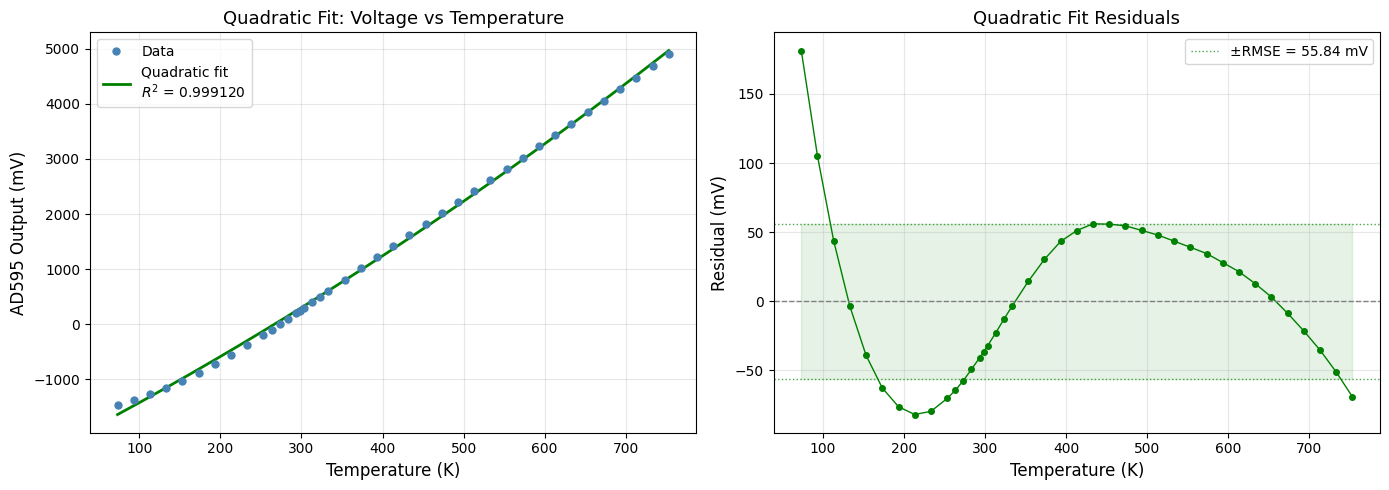

In [ ]:
# --- Quadratic Fit ---
quad_coeffs = np.polyfit(T, V, 2)
a_q, b_q, c_q = quad_coeffs
V_quad = np.polyval(quad_coeffs, T)
quad_res, quad_r2, quad_rmse = goodness_of_fit(V, V_quad, 2, 'Quadratic')

print(f'=== Quadratic Fit: V = a·T² + b·T + c ===')
print(f'  a = {a_q:.6e}  (T² coefficient)')
print(f'  b = {b_q:.6f}  (T coefficient)')
print(f'  c = {c_q:.4f}  (intercept)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(T, V, 'o', color='steelblue', markersize=5, zorder=3, label='Data')
axes[0].plot(T_smooth, np.polyval(quad_coeffs, T_smooth), '-', color='green', linewidth=2,
             label=f'Quadratic fit\n$R^2$ = {quad_r2:.6f}')
axes[0].set_xlabel('Temperature (K)', fontsize=12)
axes[0].set_ylabel('AD595 Output (mV)', fontsize=12)
axes[0].set_title('Quadratic Fit: Voltage vs Temperature', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(T, quad_res, 'o-', color='green', markersize=4, linewidth=1)
axes[1].axhline(0, color='gray', linewidth=1, linestyle='--')
axes[1].axhline( quad_rmse, color='green', linewidth=1, linestyle=':', alpha=0.7, label=f'±RMSE = {quad_rmse:.2f} mV')
axes[1].axhline(-quad_rmse, color='green', linewidth=1, linestyle=':', alpha=0.7)
axes[1].fill_between(T, -quad_rmse, quad_rmse, alpha=0.1, color='green')
axes[1].set_xlabel('Temperature (K)', fontsize=12)
axes[1].set_ylabel('Residual (mV)', fontsize=12)
axes[1].set_title('Quadratic Fit Residuals', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Goodness of Fit: Exponential ===
  R²           = 0.99904264
  Adjusted R²  = 0.99896286
  RMSE         = 58.2314 mV
  MAE          = 47.4695 mV
  Max residual = 194.8125 mV
  Reduced χ²   = 3665.8322

=== Exponential Fit: V = a·exp(b·T) + c ===
  a = 1.532744e+04
  b = 5.111932e-04 K⁻¹
  c = -17560.2571 mV


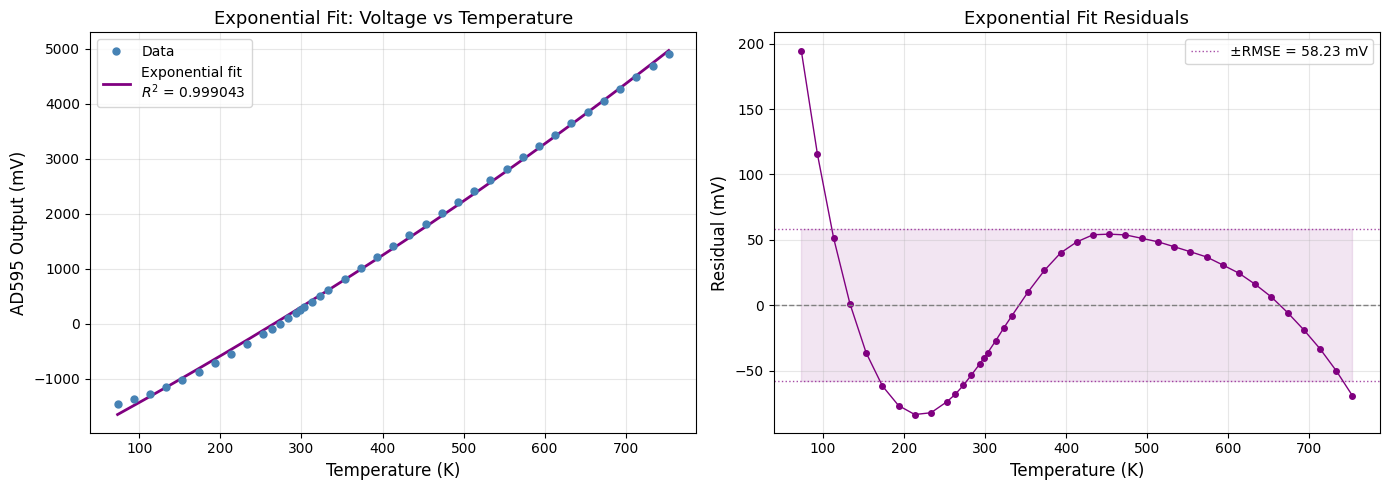

In [ ]:
# --- Exponential Fit: V = a * exp(b * T) + c ---
def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c

exp_params, _ = curve_fit(exp_model, T, V, p0=[1.0, 0.01, -500], maxfev=10000)
a_e, b_e, c_e = exp_params
V_exp = exp_model(T, *exp_params)
exp_res, exp_r2, exp_rmse = goodness_of_fit(V, V_exp, 3, 'Exponential')

print(f'=== Exponential Fit: V = a·exp(b·T) + c ===')
print(f'  a = {a_e:.6e}')
print(f'  b = {b_e:.6e} K⁻¹')
print(f'  c = {c_e:.4f} mV')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(T, V, 'o', color='steelblue', markersize=5, zorder=3, label='Data')
axes[0].plot(T_smooth, exp_model(T_smooth, *exp_params), '-', color='purple', linewidth=2,
             label=f'Exponential fit\n$R^2$ = {exp_r2:.6f}')
axes[0].set_xlabel('Temperature (K)', fontsize=12)
axes[0].set_ylabel('AD595 Output (mV)', fontsize=12)
axes[0].set_title('Exponential Fit: Voltage vs Temperature', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(T, exp_res, 'o-', color='purple', markersize=4, linewidth=1)
axes[1].axhline(0, color='gray', linewidth=1, linestyle='--')
axes[1].axhline( exp_rmse, color='purple', linewidth=1, linestyle=':', alpha=0.7, label=f'±RMSE = {exp_rmse:.2f} mV')
axes[1].axhline(-exp_rmse, color='purple', linewidth=1, linestyle=':', alpha=0.7)
axes[1].fill_between(T, -exp_rmse, exp_rmse, alpha=0.1, color='purple')
axes[1].set_xlabel('Temperature (K)', fontsize=12)
axes[1].set_ylabel('Residual (mV)', fontsize=12)
axes[1].set_title('Exponential Fit Residuals', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Goodness of Fit: 1/ln(T) ===
  R²           = 0.78279670
  Adjusted R²  = 0.77105598
  RMSE         = 877.1094 mV
  MAE          = 744.7217 mV
  Max residual = 2386.4925 mV
  Reduced χ²   = 809811.5154

=== 1/ln Fit: V = a/ln(T) + b ===
  a = -86288.9055 mV
  b = 16261.7000 mV


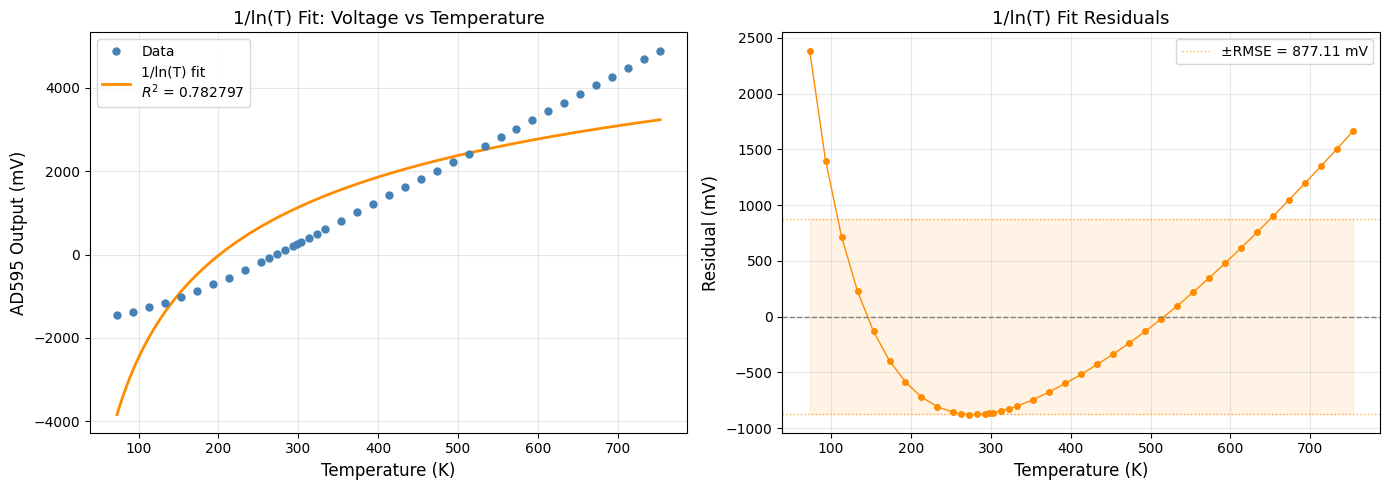

In [ ]:
# --- 1/ln Fit: V = a / ln(T) + b ---
X_invln = 1.0 / np.log(T)
invln_coeffs = np.polyfit(X_invln, V, 1)
a_il, b_il = invln_coeffs
V_invln = np.polyval(invln_coeffs, X_invln)
invln_res, invln_r2, invln_rmse = goodness_of_fit(V, V_invln, 2, '1/ln(T)')

print(f'=== 1/ln Fit: V = a/ln(T) + b ===')
print(f'  a = {a_il:.4f} mV')
print(f'  b = {b_il:.4f} mV')

X_smooth_invln = 1.0 / np.log(T_smooth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(T, V, 'o', color='steelblue', markersize=5, zorder=3, label='Data')
axes[0].plot(T_smooth, np.polyval(invln_coeffs, X_smooth_invln), '-', color='darkorange', linewidth=2,
             label=f'1/ln(T) fit\n$R^2$ = {invln_r2:.6f}')
axes[0].set_xlabel('Temperature (K)', fontsize=12)
axes[0].set_ylabel('AD595 Output (mV)', fontsize=12)
axes[0].set_title('1/ln(T) Fit: Voltage vs Temperature', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(T, invln_res, 'o-', color='darkorange', markersize=4, linewidth=1)
axes[1].axhline(0, color='gray', linewidth=1, linestyle='--')
axes[1].axhline( invln_rmse, color='darkorange', linewidth=1, linestyle=':', alpha=0.7, label=f'±RMSE = {invln_rmse:.2f} mV')
axes[1].axhline(-invln_rmse, color='darkorange', linewidth=1, linestyle=':', alpha=0.7)
axes[1].fill_between(T, -invln_rmse, invln_rmse, alpha=0.1, color='darkorange')
axes[1].set_xlabel('Temperature (K)', fontsize=12)
axes[1].set_ylabel('Residual (mV)', fontsize=12)
axes[1].set_title('1/ln(T) Fit Residuals', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Goodness of Fit: Cubic ===
  R²           = 0.99976476
  Adjusted R²  = 0.99973788
  RMSE         = 28.8653 mV
  MAE          = 24.5329 mV
  Max residual = 71.0795 mV
  Reduced χ²   = 925.7828

=== Cubic Fit: V = a·T̃³ + b·T̃² + c·T̃ + d  (T̃ = (T−μ)/σ) ===
  a = -5.371838e+01
  b = 1.037465e+02
  c = 1961.945128
  d = 1227.4515
  μ = 398.27 K,  σ = 193.13 K

  → RMSE vs quadratic: 55.8422 → 28.8653 mV  (48.3% reduction)


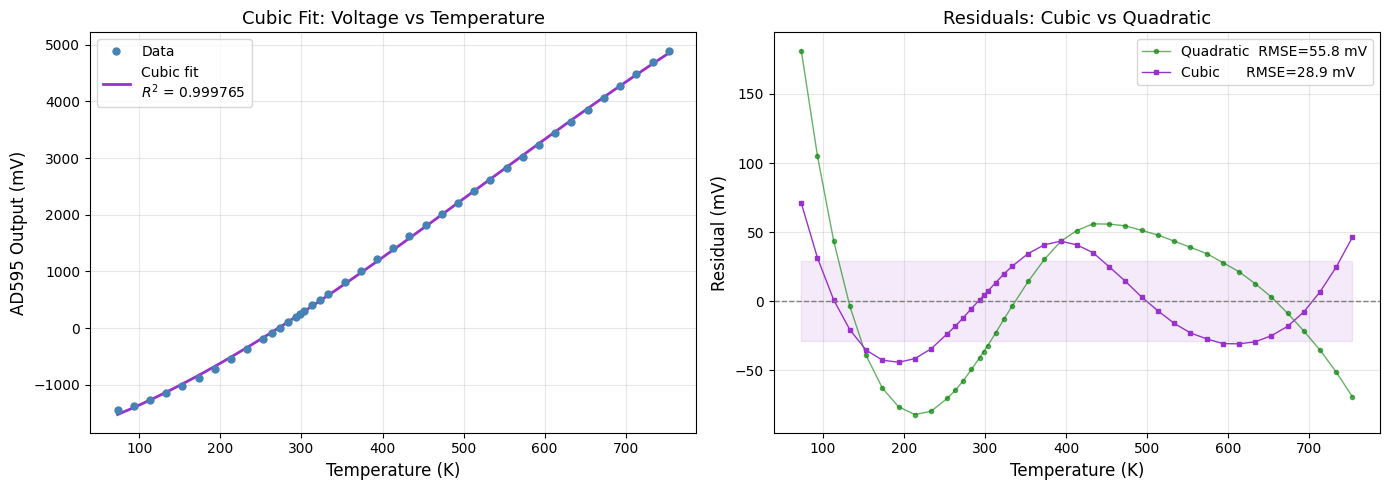

In [ ]:
# --- Cubic Fit (recommended) ---
# Normalize T to avoid numerical conditioning issues with large K values cubed
T_norm = (T - T_mean) / T_std
T_smooth_norm = (T_smooth - T_mean) / T_std

cubic_coeffs = np.polyfit(T_norm, V, 3)
a3, a2, a1, a0 = cubic_coeffs
V_cubic = np.polyval(cubic_coeffs, T_norm)
cubic_res, cubic_r2, cubic_rmse = goodness_of_fit(V, V_cubic, 4, 'Cubic')

print(f'=== Cubic Fit: V = a·T̃³ + b·T̃² + c·T̃ + d  (T̃ = (T−μ)/σ) ===')
print(f'  a = {a3:.6e}')
print(f'  b = {a2:.6e}')
print(f'  c = {a1:.6f}')
print(f'  d = {a0:.4f}')
print(f'  μ = {T_mean:.2f} K,  σ = {T_std:.2f} K')
print()
print(f'  → RMSE vs quadratic: {quad_rmse:.4f} → {cubic_rmse:.4f} mV  ({(1 - cubic_rmse/quad_rmse)*100:.1f}% reduction)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(T, V, 'o', color='steelblue', markersize=5, zorder=3, label='Data')
axes[0].plot(T_smooth, np.polyval(cubic_coeffs, T_smooth_norm), '-', color='darkorchid', linewidth=2,
             label=f'Cubic fit\n$R^2$ = {cubic_r2:.6f}')
axes[0].set_xlabel('Temperature (K)', fontsize=12)
axes[0].set_ylabel('AD595 Output (mV)', fontsize=12)
axes[0].set_title('Cubic Fit: Voltage vs Temperature', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(T, quad_res,  'o-', color='green',      markersize=3, linewidth=1, alpha=0.6, label=f'Quadratic  RMSE={quad_rmse:.1f} mV')
axes[1].plot(T, cubic_res, 's-', color='darkorchid', markersize=3, linewidth=1,             label=f'Cubic      RMSE={cubic_rmse:.1f} mV')
axes[1].axhline(0, color='gray', linewidth=1, linestyle='--')
axes[1].fill_between(T, -cubic_rmse, cubic_rmse, alpha=0.1, color='darkorchid')
axes[1].set_xlabel('Temperature (K)', fontsize=12)
axes[1].set_ylabel('Residual (mV)', fontsize=12)
axes[1].set_title('Residuals: Cubic vs Quadratic', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def solve_cubic_temperature(v_mV, Tmin=74.0, Tmax=730.0, tol=1e-6):
    coeffs = [a3, a2, a1, a0 - v_mV]
    roots = np.roots(coeffs)

    real_roots = roots[np.abs(roots.imag) < tol].real
    T_candidates = real_roots * T_std + T_mean
    T_valid = T_candidates[(T_candidates >= Tmin) & (T_candidates <= Tmax)]
    T_valid = np.unique(np.round(T_valid, 9))
    return T_valid

def solve_temperature_from_volts(v_V, Tmin=74.0, Tmax=730.0):
    v_mV = float(v_V) * 1000.0
    T_sol_K = solve_cubic_temperature(v_mV, Tmin=Tmin, Tmax=Tmax)

    if T_sol_K.size == 0:
        print(f"No valid temperature solution for {v_V:.6f} V ({v_mV:.3f} mV) in [{Tmin}, {Tmax}] K.")
        return T_sol_K

    print(f"Input: {v_V:.6f} V ({v_mV:.3f} mV)")
    print("Temperature solution(s):")
    for tK in T_sol_K:
        print(f"  {tK:.6f} K  ({tK - 273.15:.6f} °C)")
    return T_sol_K

# Enter your voltage here (in Volts):
solve_temperature_from_volts(0.200)